In [51]:
import pandas as pd
import numpy as np

## overall ranks

In [52]:
results_df = pd.read_excel('/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_lf_bag_cv.xlsx', sheet_name="disease")

In [53]:
results_df.columns

Index(['method', 'para', 'top_recall_300', 'top_recall_10%', 'auroc',
       'rank_ratio', 'bedroc_1', 'bedroc_5', 'bedroc_10', 'bedroc_30',
       'weights_1', 'weights_2', 'weights_3', 'disease', 'category'],
      dtype='object')

In [54]:

# assuming results_df is your DataFrame

# get rows with max bedroc_1 per disease
best_bedroc = results_df.loc[
    results_df.groupby("disease")["bedroc_1"].idxmax()
]

# get rows with max auroc per disease
best_auroc = results_df.loc[
    results_df.groupby("disease")["auroc"].idxmax()
]

# combine them (avoid duplicates if the same row is best in both)
best_combined = pd.concat([best_bedroc, best_auroc]).drop_duplicates()
best_combined


,method,para,top_recall_300,top_recall_10%,auroc,rank_ratio,bedroc_1,bedroc_5,bedroc_10,bedroc_30,weights_1,weights_2,weights_3,disease,category
8,random_negative,later_fused_bag_1_ppi,0.600,0.840,0.899,0.102,0.282,0.528,0.633,0.775,0.089,0.043,0.124,ICD10_C16,Neoplasms
26,random_negative,later_fused_bag_1_ppi,0.556,0.889,0.911,0.089,0.368,0.563,0.663,0.794,0.063,0.018,0.078,ICD10_C18,Neoplasms
41,random_negative,uniport_seq,1.000,1.000,0.993,0.007,0.327,0.799,0.894,0.964,0.091,0.000,0.086,ICD10_C23,Neoplasms
54,random_negative,uniport_ppi_2019,0.000,0.000,0.850,0.150,0.000,0.008,0.089,0.449,0.119,0.001,0.118,ICD10_C43,Neoplasms
86,random_negative,later_fused_bag_2_uniport_esm,0.082,0.148,0.551,0.450,0.041,0.084,0.114,0.233,0.183,0.000,0.182,ICD10_C50,Neoplasms
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686,random_negative,diffusion_2019,0.000,1.000,0.972,0.028,0.013,0.413,0.643,0.864,0.123,0.000,0.127,ICD10_L40,Diseases of the skin and subcutaneous tissue
708,random_negative,later_fused_all,1.000,1.000,0.995,0.005,0.433,0.846,0.920,0.973,0.146,0.005,0.153,ICD10_M32,Diseases of the musculoskeletal system and con...
791,random_negative,later_fused_ppi,0.000,0.200,0.721,0.279,0.000,0.034,0.116,0.348,0.173,0.002,0.176,ICD10_N17,Diseases of the genitourinary system
824,random_negative,later_fused_bag_2_uniport_esm,0.143,0.714,0.880,0.120,0.058,0.345,0.490,0.674,0.009,0.000,0.011,ICD10_N46,Diseases of the genitourinary system


In [55]:
import matplotlib.pyplot as plt

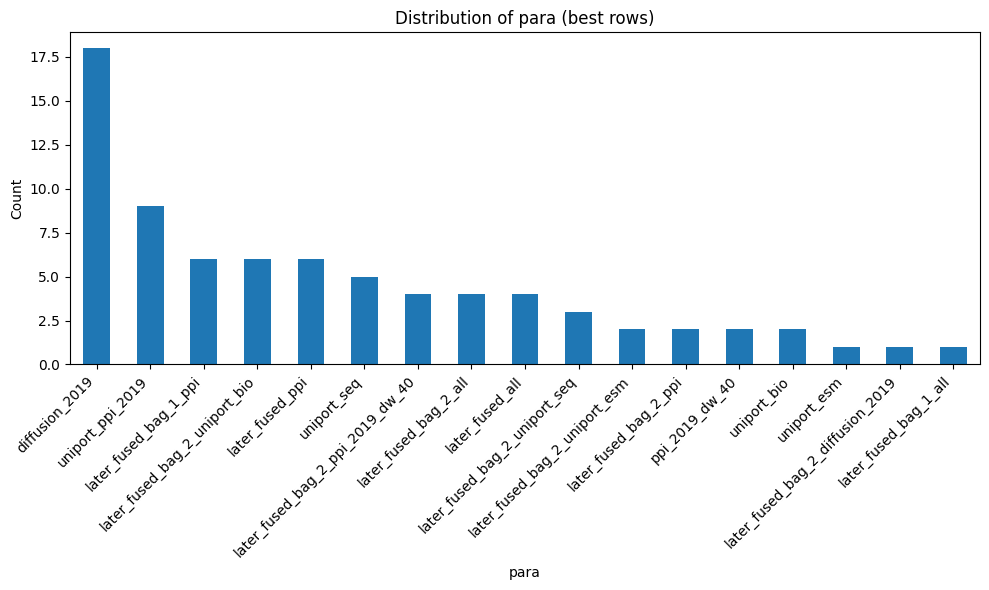

In [56]:
counts = best_combined['para'].value_counts()

plt.figure(figsize=(10, 6))
counts.plot(kind="bar")

plt.xlabel("para")
plt.ylabel("Count")
plt.title("Distribution of para (best rows)")
plt.xticks(rotation=45, ha="right")  # tilt labels to avoid overlap
plt.tight_layout()
plt.show()


In [57]:

def approx_rank(group, col, tol=0.01):
    # sort descending
    group = group.sort_values(col, ascending=False).copy()
    
    ranks = []
    current_rank = 1
    prev_val = None
    for i, val in enumerate(group[col]):
        if prev_val is not None and abs(prev_val - val) < tol:
            # same rank as previous
            ranks.append(current_rank)
        else:
            # new rank = previous max rank + number of unique ranks
            current_rank = len(set(ranks)) + 1
            ranks.append(current_rank)
        prev_val = val
    
    group[col + "_rank"] = ranks
    return group

# apply to each disease for both metrics
results_ranked = results_df.groupby("disease", group_keys=False).apply(
    lambda g: approx_rank(g, "auroc", tol=0.01)
)
results_ranked = results_ranked.groupby("disease", group_keys=False).apply(
    lambda g: approx_rank(g, "bedroc_1", tol=0.01)
)

# now results_ranked has two new columns: auroc_rank, bedroc_1_rank


/tmp/ipykernel_1753839/1977463720.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_ranked = results_df.groupby("disease", group_keys=False).apply(
/tmp/ipykernel_1753839/1977463720.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_ranked = results_ranked.groupby("disease", group_keys=False).apply(


In [58]:
results_ranked 

,method,para,top_recall_300,top_recall_10%,auroc,rank_ratio,bedroc_1,bedroc_5,bedroc_10,bedroc_30,weights_1,weights_2,weights_3,disease,category,auroc_rank,bedroc_1_rank
8,random_negative,later_fused_bag_1_ppi,0.60,0.84,0.899,0.102,0.282,0.528,0.633,0.775,0.089,0.043,0.124,ICD10_C16,Neoplasms,1,1
17,random_negative,later_fused_ppi,0.60,0.84,0.910,0.091,0.280,0.538,0.649,0.791,0.102,0.047,0.139,ICD10_C16,Neoplasms,1,1
15,random_negative,later_fused_bag_2_uniport_ppi_2019,0.56,0.72,0.892,0.093,0.272,0.505,0.602,0.754,0.105,0.050,0.143,ICD10_C16,Neoplasms,1,1
11,random_negative,later_fused_bag_2_ppi,0.52,0.80,0.902,0.099,0.263,0.506,0.617,0.767,0.089,0.042,0.123,ICD10_C16,Neoplasms,1,1
0,random_negative,uniport_ppi_2019,0.52,0.72,0.889,0.112,0.259,0.488,0.590,0.748,0.107,0.051,0.146,ICD10_C16,Neoplasms,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,random_negative,uniport_esm,0.50,0.50,0.895,0.105,0.148,0.393,0.462,0.650,0.101,0.003,0.100,ICD10_N97,Diseases of the genitourinary system,3,8
859,random_negative,later_fused_bag_2_uniport_bio,0.50,0.50,0.915,0.086,0.027,0.282,0.416,0.675,0.092,0.004,0.089,ICD10_N97,Diseases of the genitourinary system,2,9
849,random_negative,uniport_bio,0.00,0.50,0.913,0.087,0.019,0.263,0.403,0.670,0.095,0.004,0.092,ICD10_N97,Diseases of the genitourinary system,2,9
862,random_negative,later_fused_bag_2_uniport_seq,0.00,0.50,0.924,0.076,0.010,0.235,0.401,0.692,0.115,0.005,0.112,ICD10_N97,Diseases of the genitourinary system,2,9


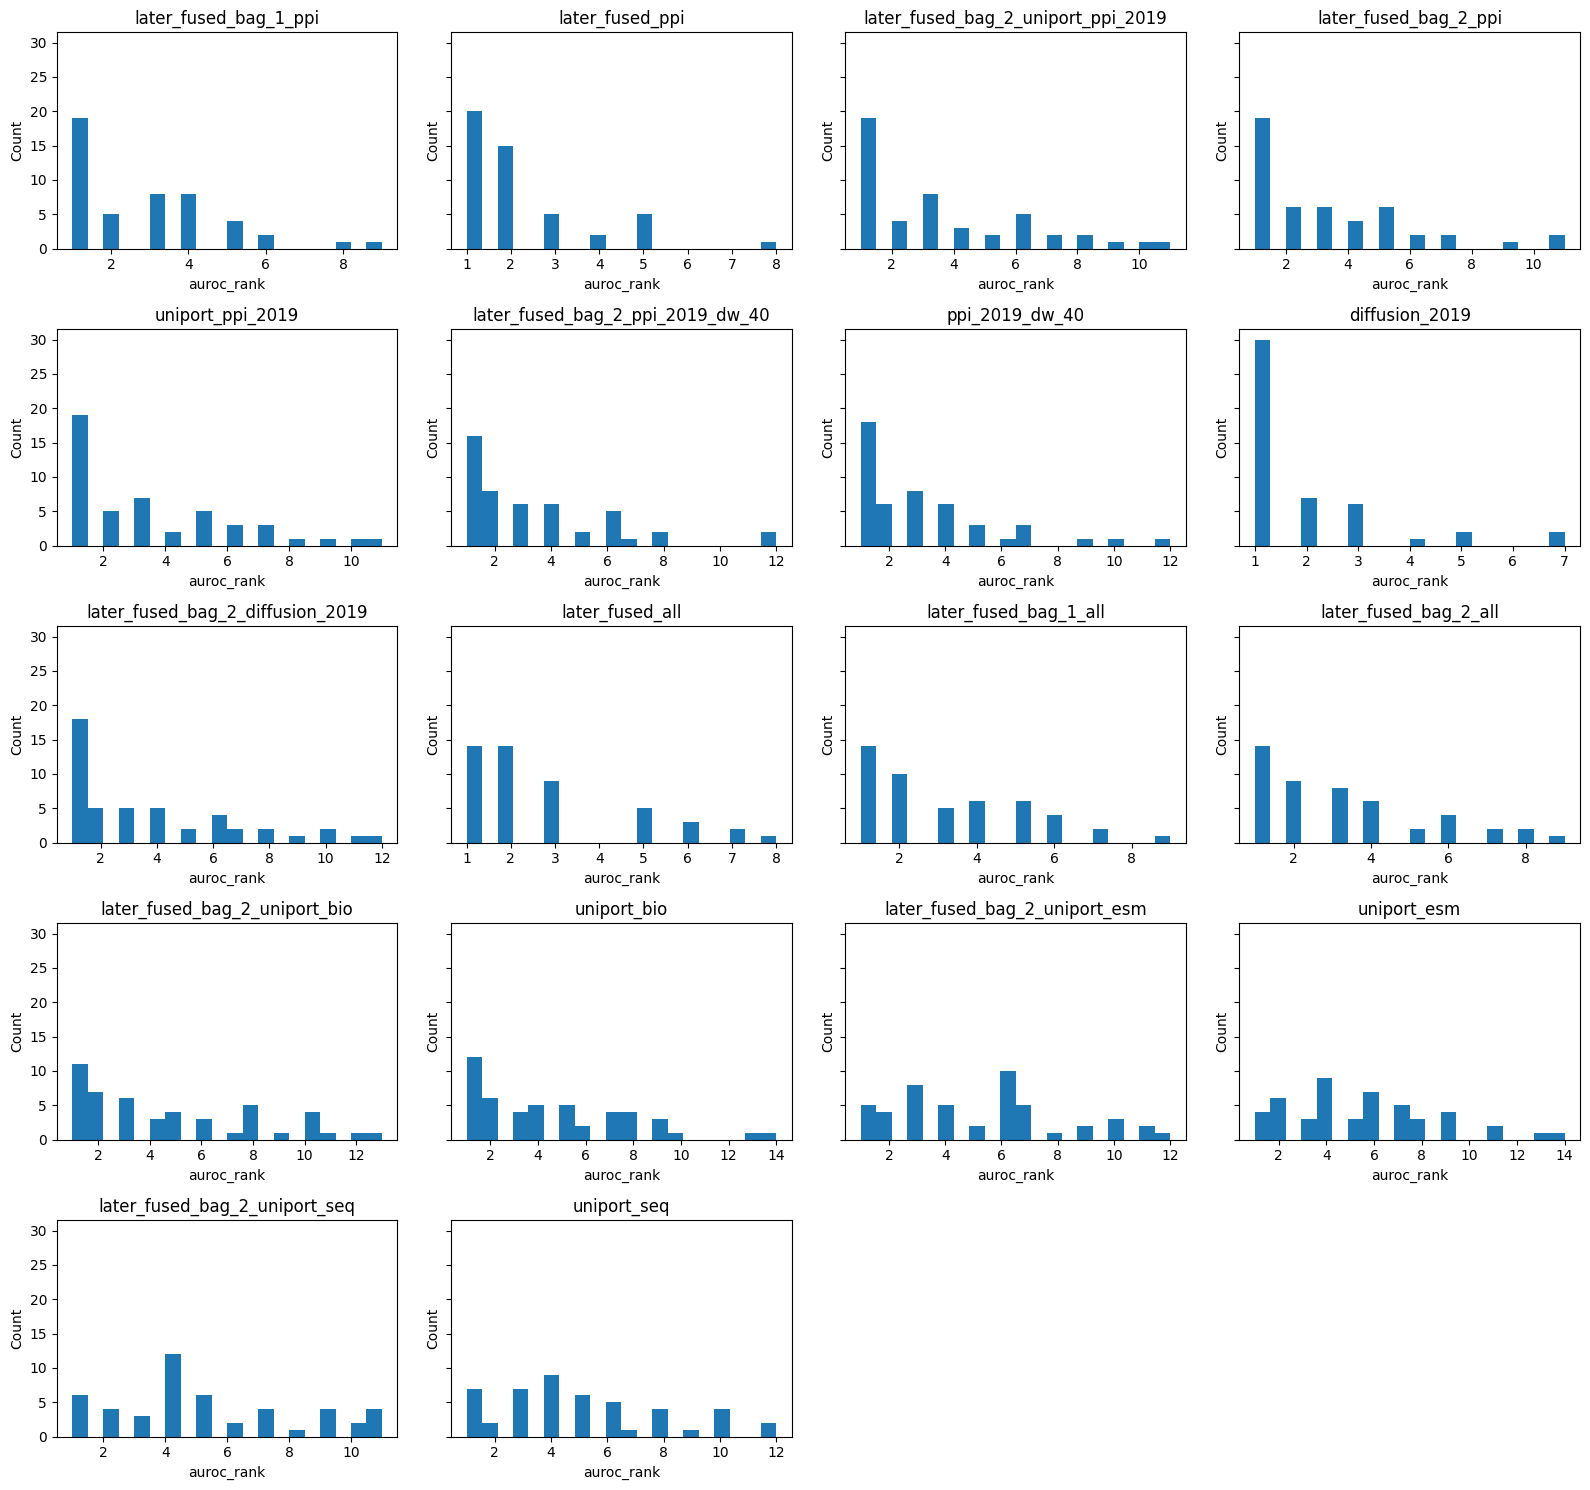

In [59]:
import math

# get all unique para values
paras = results_ranked['para'].unique()
n = len(paras)

# layout: square-ish grid
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharey=True)
axes = axes.flatten()

for i, feature in enumerate(paras):
    ax = axes[i]
    subset = results_ranked[results_ranked['para'] == feature]
    ax.hist(subset['auroc_rank'], bins=20)
    ax.set_title(str(feature))
    ax.set_xlabel("auroc_rank")
    ax.set_ylabel("Count")

# remove empty axes if paras < rows*cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [62]:
# select only float and int columns
float_cols = results_ranked.select_dtypes(include=["float", "int"]).columns

# group by 'para' and compute mean and variance
para_stats = (
    results_ranked
    .groupby("para")[float_cols]
    .agg(["mean", "var"])
    .reset_index()
)

In [ ]:

para_stats.sort_values("auroc_rank", ascending=True)

para top_recall_300            \
                                                 mean       var   
0                       diffusion_2019       0.385771  0.143350   
1                      later_fused_all       0.219625  0.101793   
2                later_fused_bag_1_all       0.256979  0.121443   
3                later_fused_bag_1_ppi       0.349375  0.144711   
4                later_fused_bag_2_all       0.241437  0.109959   
5     later_fused_bag_2_diffusion_2019       0.366979  0.145710   
6                later_fused_bag_2_ppi       0.336521  0.141871   
7     later_fused_bag_2_ppi_2019_dw_40       0.315125  0.134104   
8        later_fused_bag_2_uniport_bio       0.200146  0.095146   
9        later_fused_bag_2_uniport_esm       0.137813  0.068944   
10  later_fused_bag_2_uniport_ppi_2019       0.303604  0.137346   
11       later_fused_bag_2_uniport_seq       0.157688  0.075765   
12                     later_fused_ppi       0.346396  0.146393   
13                      ppi_2019_dw_40       0.315354  0.133901   
14                         uniport_bio       0.185646  0.094452   
15                         uniport_esm       0.112063  0.053168   
16                    uniport_ppi_2019       0.303833  0.136945   
17                         uniport_seq       0.163604  0.077074   

   top_recall_10%               auroc           rank_ratio            \
             mean       var      mean       var       mean       var   
0        0.609208  0.131628  0.879458  0.015089   0.120667  0.015088   
1        0.562688  0.132863  0.835208  0.022494   0.169792  0.024348   
2        0.536854  0.135159  0.822063  0.025422   0.179188  0.026057   
3        0.611042  0.145147  0.835604  0.024491   0.168646  0.028808   
4        0.500771  0.145321  0.817021  0.026972   0.183187  0.026972   
5        0.531854  0.142707  0.800979  0.035193   0.227625  0.059190   
6        0.600021  0.142344  0.823125  0.028646   0.177813  0.029312   
7        0.582688  0.142702  0.818812  0.027518   0.191187  0.034644   
8        0.423479  0.135455  0.722083  0.046103   0.308958  0.068822   
9        0.297437  0.115086  0.676667  0.042191   0.343833  0.058428   
10       0.557229  0.160452  0.808833  0.033909   0.204208  0.046450   
11       0.317896  0.098310  0.667417  0.048155   0.350188  0.064022   
12       0.672979  0.120018  0.861146  0.017163   0.144958  0.019421   
13       0.585292  0.148572  0.825042  0.024675   0.175021  0.024680   
14       0.418563  0.135017  0.734604  0.039228   0.265542  0.039221   
15       0.302354  0.114382  0.662729  0.047582   0.337396  0.047567   
16       0.556604  0.160807  0.808396  0.037248   0.191729  0.037240   
17       0.315292  0.098997  0.678750  0.044357   0.321333  0.044328   

    bedroc_1  ... weights_1           weights_2           weights_3            \
        mean  ...      mean       var      mean       var      mean       var   
0   0.173875  ...  0.099667  0.006810  0.012188  0.000621  0.101354  0.007323   
1   0.114729  ...  0.097125  0.006301  0.009583  0.000263  0.097792  0.006589   
2   0.108375  ...  0.092396  0.005447  0.009354  0.000248  0.092896  0.005695   
3   0.183333  ...  0.088875  0.005313  0.009042  0.000250  0.089979  0.005628   
4   0.105021  ...  0.090750  0.005217  0.009104  0.000228  0.091792  0.005542   
5   0.170021  ...  0.086583  0.004696  0.009208  0.000272  0.087896  0.005030   
6   0.171167  ...  0.087917  0.005182  0.008958  0.000244  0.089229  0.005488   
7   0.146250  ...  0.096229  0.006297  0.009562  0.000281  0.097521  0.006586   
8   0.092771  ...  0.124646  0.008557  0.013042  0.000544  0.125521  0.009024   
9   0.073375  ...  0.113542  0.006064  0.011438  0.000473  0.112583  0.006537   
10  0.145167  ...  0.094375  0.006150  0.007917  0.000189  0.094229  0.006536   
11  0.076604  ...  0.114521  0.006241  0.011333  0.000463  0.113354  0.006714   
12  0.178271  ...  0.096479  0.006506  0.009750  0.000307  0.097625  0.006832   
13  0.140375  ...  0.096417  0.006293

In [ ]:
# select only float columns 
float_cols = results_ranked.select_dtypes(include=["float", "int"]).columns 
# group by para and compute mean 
para_means = results_ranked.groupby("para")[float_cols].mean().reset_index() 
para_means.sort_values("bedroc_1_rank", ascending=True)
para_means.sort_values("auroc_rank", ascending=True)

,para,top_recall_300,top_recall_10%,auroc,rank_ratio,bedroc_1,bedroc_5,bedroc_10,bedroc_30,weights_1,weights_2,weights_3,auroc_rank,bedroc_1_rank
0,diffusion_2019,0.385771,0.609208,0.879458,0.120667,0.173875,0.370604,0.477708,0.671604,0.099667,0.012188,0.101354,1.875000,2.458333
12,later_fused_ppi,0.346396,0.672979,0.861146,0.144958,0.178271,0.355563,0.463875,0.653229,0.096479,0.009750,0.097625,2.208333,2.458333
3,later_fused_bag_1_ppi,0.349375,0.611042,0.835604,0.168646,0.183333,0.341687,0.436625,0.616792,0.088875,0.009042,0.089979,2.791667,2.312500
1,later_fused_all,0.219625,0.562688,0.835208,0.169792,0.114729,0.281688,0.395000,0.600542,0.097125,0.009583,0.097792,2.791667,3.208333
2,later_fused_bag_1_all,0.256979,0.536854,0.822063,0.179188,0.108375,0.275583,0.382688,0.580417,0.092396,0.009354,0.092896,3.125000,3.333333
13,ppi_2019_dw_40,0.315354,0.585292,0.825042,0.175021,0.140375,0.304000,0.403021,0.587917,0.096417,0.009708,0.097875,3.145833,3.291667
6,later_fused_bag_2_ppi,0.336521,0.600021,0.823125,0.177813,0.171167,0.328188,0.422563,0.603250,0.087917,0.008958,0.089229,3.166667,2.645833
4,later_fused_bag_2_all,0.241437,0.500771,0.817021,0.183187,0.105021,0.257021,0.358937,0.562208,0.090750,0.009104,0.091792,3.187500,3.500000
16,uniport_ppi_2019,0.303833,0.556604,0.808396,0.191729,0.142729,0.299333,0.398062,0.586229,0.094938,0.009458,0.096229,3.333333,3.208333
7,later_fused_bag_2_ppi_2019_dw_40,0.315125,0.582688,0.818812,0.191187,0.146250,0.310271,0.408458,0.590000,0.096229,0.009562,0.097521,3.354167,3.166667


## why fusion fail

### take C23 as exmaple

In [18]:
C23_df = results_ranked[results_ranked['disease']=='ICD10_C23']

C23_df.sort_values("auroc_rank", ascending=True)

,method,para,top_recall_300,top_recall_10%,auroc,rank_ratio,bedroc_1,bedroc_5,bedroc_10,bedroc_30,weights_1,weights_2,weights_3,disease,category,auroc_rank,bedroc_1_rank
41,random_negative,uniport_seq,1.0,1.0,0.993,0.007,0.327,0.799,0.894,0.964,0.091,0.0,0.086,ICD10_C23,Neoplasms,1,1
52,random_negative,later_fused_bag_2_uniport_seq,1.0,1.0,0.992,0.008,0.286,0.778,0.882,0.959,0.091,0.0,0.085,ICD10_C23,Neoplasms,1,2
50,random_negative,later_fused_bag_2_uniport_esm,1.0,1.0,0.987,0.013,0.128,0.663,0.814,0.934,0.093,0.0,0.089,ICD10_C23,Neoplasms,1,3
46,random_negative,later_fused_bag_2_diffusion_2019,1.0,1.0,0.982,0.018,0.059,0.568,0.754,0.911,0.045,0.0,0.043,ICD10_C23,Neoplasms,1,4
38,random_negative,diffusion_2019,1.0,1.0,0.982,0.018,0.057,0.564,0.751,0.909,0.047,0.0,0.045,ICD10_C23,Neoplasms,1,4
40,random_negative,uniport_esm,0.0,1.0,0.980,0.020,0.043,0.533,0.730,0.901,0.091,0.0,0.086,ICD10_C23,Neoplasms,1,5
42,random_negative,later_fused_all,0.0,1.0,0.967,0.033,0.005,0.344,0.587,0.838,0.049,0.0,0.046,ICD10_C23,Neoplasms,2,6
43,random_negative,later_fused_bag_1_all,0.0,1.0,0.960,0.040,0.002,0.276,0.526,0.808,0.046,0.0,0.044,ICD10_C23,Neoplasms,2,6
45,random_negative,later_fused_bag_2_all,0.0,1.0,0.942,0.058,0.000,0.154,0.393,0.734,0.044,0.0,0.042,ICD10_C23,Neoplasms,3,6
44,random_negative,later_fused_bag_1_ppi,0.0,0.0,0.900,0.100,0.000,0.040,0.199,0.586,0.045,0.0,0.043,ICD10_C23,Neoplasms,4,6


In [22]:
import pickle

# Load predictions
file_path = "/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_lf_bag_cv_pred/ICD10_C23_pred.pkl"

with open(file_path, "rb") as f:
    preds = pickle.load(f)

true_label = preds["true_label"]

# Indices of true positives
positive_idx = np.where(true_label == 1)[0]

results = {}

for method, scores in preds.items():
    if method == "true_label":
        continue
    
    # argsort gives ascending order, so reverse for ranking highest first
    ranking = np.argsort(scores)[::-1]
    
    # find rank position(s) of positives
    ranks = [np.where(ranking == idx)[0][0] + 1 for idx in positive_idx]  # +1 for 1-based rank
    
    results[method] = ranks

# Print results
for method, ranks in results.items():
    print(f"{method}: {ranks}")


uniport_ppi_2019: [2563]
ppi_2019_dw_40: [3733]
diffusion_2019: [280]
uniport_bio: [11786]
uniport_seq: [110]
uniport_esm: [307]


In [23]:
len(preds['true_label'])

15669

In [24]:
3733/15669

0.23824111302571957

In [29]:
results_ranked.columns

Index(['method', 'para', 'top_recall_300', 'top_recall_10%', 'auroc',
       'rank_ratio', 'bedroc_1', 'bedroc_5', 'bedroc_10', 'bedroc_30',
       'weights_1', 'weights_2', 'weights_3', 'disease', 'category',
       'auroc_rank', 'bedroc_1_rank', 'train_sum_x', 'test_sum_x',
       'train_sum_y', 'test_sum_y'],
      dtype='object')

In [31]:
results_ranked = results_ranked.drop(
    columns=['train_sum_x', 'test_sum_x', 'train_sum_y', 'test_sum_y'], 
    errors='ignore'
)


In [32]:
train_test = pd.read_excel('/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_df.xlsx', sheet_name="disease")
results_ranked = results_ranked.merge(
    train_test[['disease', 'train_sum', 'test_sum']],
    on='disease',
    how='left'  # optional: ensures each disease in results_ranked matches at most 1 row in train_test
)

In [37]:
results_ranked.drop_duplicates(inplace=True)


In [38]:
results_ranked_test_3 = results_ranked[results_ranked['test_sum']>=3]

In [40]:
len(results_ranked_test_3['disease'].unique()),len(results_ranked['disease'].unique())

(26, 48)

In [41]:
# select only float columns
float_cols = results_ranked_test_3.select_dtypes(include=["float", "int"]).columns


# group by para and compute mean
para_means = results_ranked_test_3.groupby("para")[float_cols].mean().reset_index()
para_means.sort_values("bedroc_1_rank", ascending=True)

,para,top_recall_300,top_recall_10%,auroc,rank_ratio,bedroc_1,bedroc_5,bedroc_10,bedroc_30,weights_1,weights_2,weights_3,auroc_rank,bedroc_1_rank,train_sum,test_sum
3,later_fused_bag_1_ppi,0.241154,0.512692,0.773808,0.233923,0.128346,0.251769,0.341385,0.525885,0.097308,0.011731,0.104077,3.230769,2.153846,124.038462,11.923077
12,later_fused_ppi,0.235654,0.588577,0.811231,0.200000,0.130577,0.273962,0.379154,0.574885,0.105923,0.012692,0.113077,2.384615,2.153846,124.038462,11.923077
0,diffusion_2019,0.250654,0.528538,0.838885,0.161346,0.123500,0.277269,0.381346,0.590385,0.108385,0.016846,0.116538,2.000000,2.307692,124.038462,11.923077
6,later_fused_bag_2_ppi,0.217423,0.511577,0.761731,0.239923,0.119692,0.239192,0.328885,0.515846,0.096231,0.011538,0.103154,3.692308,2.423077,124.038462,11.923077
5,later_fused_bag_2_diffusion_2019,0.215962,0.424192,0.746308,0.277923,0.114462,0.233423,0.314423,0.496269,0.094962,0.012038,0.102000,4.346154,2.461538,124.038462,11.923077
7,later_fused_bag_2_ppi_2019_dw_40,0.216385,0.479577,0.753500,0.264962,0.110615,0.231692,0.322654,0.506577,0.105385,0.012154,0.112654,4.038462,2.615385,124.038462,11.923077
13,ppi_2019_dw_40,0.216808,0.484385,0.765808,0.234269,0.107962,0.228231,0.318692,0.505038,0.105692,0.012346,0.113115,3.615385,2.653846,124.038462,11.923077
1,later_fused_all,0.174692,0.461885,0.790692,0.218423,0.092000,0.216615,0.317000,0.527115,0.105885,0.012115,0.112615,2.884615,2.730769,124.038462,11.923077
10,later_fused_bag_2_uniport_ppi_2019,0.214346,0.451808,0.755154,0.257538,0.099923,0.224231,0.314231,0.503923,0.103308,0.009385,0.107962,3.807692,2.730769,124.038462,11.923077
16,uniport_ppi_2019,0.214769,0.450654,0.761231,0.238962,0.097538,0.219615,0.310346,0.503346,0.104423,0.012115,0.111538,3.653846,2.769231,124.038462,11.923077


In [42]:
para_means.sort_values("auroc_rank", ascending=True)

,para,top_recall_300,top_recall_10%,auroc,rank_ratio,bedroc_1,bedroc_5,bedroc_10,bedroc_30,weights_1,weights_2,weights_3,auroc_rank,bedroc_1_rank,train_sum,test_sum
0,diffusion_2019,0.250654,0.528538,0.838885,0.161346,0.123500,0.277269,0.381346,0.590385,0.108385,0.016846,0.116538,2.000000,2.307692,124.038462,11.923077
12,later_fused_ppi,0.235654,0.588577,0.811231,0.200000,0.130577,0.273962,0.379154,0.574885,0.105923,0.012692,0.113077,2.384615,2.153846,124.038462,11.923077
1,later_fused_all,0.174692,0.461885,0.790692,0.218423,0.092000,0.216615,0.317000,0.527115,0.105885,0.012115,0.112615,2.884615,2.730769,124.038462,11.923077
2,later_fused_bag_1_all,0.166731,0.433423,0.780385,0.221808,0.085692,0.204423,0.300269,0.506654,0.100038,0.011692,0.106654,3.115385,2.884615,124.038462,11.923077
3,later_fused_bag_1_ppi,0.241154,0.512692,0.773808,0.233923,0.128346,0.251769,0.341385,0.525885,0.097308,0.011731,0.104077,3.230769,2.153846,124.038462,11.923077
4,later_fused_bag_2_all,0.176500,0.424500,0.776308,0.224000,0.083115,0.189346,0.281115,0.493231,0.098846,0.011577,0.105577,3.346154,3.038462,124.038462,11.923077
13,ppi_2019_dw_40,0.216808,0.484385,0.765808,0.234269,0.107962,0.228231,0.318692,0.505038,0.105692,0.012346,0.113115,3.615385,2.653846,124.038462,11.923077
16,uniport_ppi_2019,0.214769,0.450654,0.761231,0.238962,0.097538,0.219615,0.310346,0.503346,0.104423,0.012115,0.111538,3.653846,2.769231,124.038462,11.923077
6,later_fused_bag_2_ppi,0.217423,0.511577,0.761731,0.239923,0.119692,0.239192,0.328885,0.515846,0.096231,0.011538,0.103154,3.692308,2.423077,124.038462,11.923077
10,later_fused_bag_2_uniport_ppi_2019,0.214346,0.451808,0.755154,0.257538,0.099923,0.224231,0.314231,0.503923,0.103308,0.009385,0.107962,3.807692,2.730769,124.038462,11.923077


In [47]:
# select only float and int columns
float_cols = results_ranked_test_3.select_dtypes(include=["float", "int"]).columns

# group by category and para, compute mean
para_means = (
    results_ranked_test_3
    .groupby(["category", "para"])[float_cols]
    .mean()
    .reset_index()
)

# sort so that within each category, the best (lowest) bedroc_1_rank is on top
para_means = para_means.sort_values(
    by=["category", "bedroc_1_rank"], 
    ascending=[True, True]
).reset_index(drop=True)


In [48]:
para_means

,category,para,top_recall_300,top_recall_10%,auroc,rank_ratio,bedroc_1,bedroc_5,bedroc_10,bedroc_30,weights_1,weights_2,weights_3,auroc_rank,bedroc_1_rank,train_sum,test_sum
0,Diseases of the circulatory system,diffusion_2019,0.296800,0.673400,0.890200,0.110000,0.207200,0.352400,0.459200,0.664800,0.152400,0.020000,0.169000,1.200000,1.800000,93.8,15.600000
1,Diseases of the circulatory system,later_fused_bag_1_ppi,0.317600,0.633200,0.842000,0.158200,0.189000,0.331400,0.434400,0.623600,0.127800,0.018400,0.142200,2.200000,1.800000,93.8,15.600000
2,Diseases of the circulatory system,later_fused_bag_2_diffusion_2019,0.296800,0.566600,0.799000,0.183000,0.206400,0.324200,0.410600,0.587000,0.127800,0.019600,0.144000,4.200000,1.800000,93.8,15.600000
3,Diseases of the circulatory system,later_fused_ppi,0.317600,0.671200,0.872400,0.127800,0.190200,0.359000,0.474200,0.668800,0.135400,0.018800,0.151400,1.600000,1.800000,93.8,15.600000
4,Diseases of the circulatory system,later_fused_bag_2_ppi,0.288800,0.625600,0.826600,0.173800,0.178200,0.317000,0.419600,0.610400,0.125800,0.018200,0.140400,2.800000,2.400000,93.8,15.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,Neoplasms,later_fused_bag_2_uniport_esm,0.113333,0.314333,0.719167,0.289833,0.063833,0.139833,0.211667,0.408333,0.154833,0.040500,0.167833,4.666667,4.500000,132.0,20.166667
140,Neoplasms,uniport_bio,0.132667,0.339833,0.671167,0.329000,0.068167,0.159500,0.228667,0.386167,0.158167,0.038833,0.171500,5.666667,4.500000,132.0,20.166667
141,Neoplasms,later_fused_bag_2_uniport_seq,0.082667,0.257167,0.660167,0.353000,0.032333,0.115000,0.175667,0.349667,0.156000,0.037500,0.167500,5.166667,4.833333,132.0,20.166667
142,Neoplasms,uniport_esm,0.110000,0.314333,0.698000,0.302333,0.055833,0.131833,0.206667,0.399500,0.156333,0.041167,0.169667,5.166667,5.000000,132.0,20.166667


In [49]:
results_ranked_test_3[results_ranked_test_3['category']=='Diseases of the genitourinary system']

,method,para,top_recall_300,top_recall_10%,auroc,rank_ratio,bedroc_1,bedroc_5,bedroc_10,bedroc_30,weights_1,weights_2,weights_3,disease,category,auroc_rank,bedroc_1_rank,train_sum,test_sum
3714228,random_negative,later_fused_bag_2_ppi_2019_dw_40,0.667,1.000,0.977,0.024,0.493,0.663,0.760,0.893,0.042,0.002,0.047,ICD10_N04,Diseases of the genitourinary system,1,1,70,3
3719141,random_negative,later_fused_bag_2_uniport_bio,0.667,0.667,0.880,0.120,0.470,0.611,0.639,0.706,0.076,0.006,0.085,ICD10_N04,Diseases of the genitourinary system,5,2,70,3
3724054,random_negative,ppi_2019_dw_40,0.667,1.000,0.976,0.024,0.466,0.656,0.755,0.892,0.042,0.002,0.047,ICD10_N04,Diseases of the genitourinary system,1,2,70,3
3728967,random_negative,later_fused_bag_2_diffusion_2019,0.667,0.667,0.921,0.079,0.464,0.610,0.645,0.753,0.033,0.002,0.036,ICD10_N04,Diseases of the genitourinary system,3,2,70,3
3733880,random_negative,diffusion_2019,0.667,0.667,0.942,0.058,0.462,0.611,0.658,0.791,0.039,0.002,0.043,ICD10_N04,Diseases of the genitourinary system,2,2,70,3
3738793,random_negative,later_fused_bag_1_ppi,0.667,1.000,0.970,0.030,0.460,0.639,0.725,0.869,0.032,0.002,0.036,ICD10_N04,Diseases of the genitourinary system,1,2,70,3
3743706,random_negative,uniport_bio,0.667,0.667,0.892,0.108,0.458,0.606,0.637,0.716,0.073,0.005,0.082,ICD10_N04,Diseases of the genitourinary system,4,2,70,3
3748619,random_negative,later_fused_bag_2_ppi,0.667,1.000,0.968,0.032,0.449,0.633,0.718,0.863,0.032,0.002,0.035,ICD10_N04,Diseases of the genitourinary system,1,2,70,3
3753532,random_negative,later_fused_ppi,0.667,1.000,0.974,0.026,0.434,0.643,0.741,0.883,0.036,0.002,0.039,ICD10_N04,Diseases of the genitourinary system,1,3,70,3
3758445,random_negative,uniport_ppi_2019,0.667,1.000,0.969,0.031,0.195,0.540,0.681,0.860,0.035,0.002,0.039,ICD10_N04,Diseases of the genitourinary system,1,4,70,3


In [50]:
### N04
import pickle

# Load predictions
file_path = "/itf-fi-ml/shared/users/ziyuzh/svm/results/2019_lf_bag_cv_pred/ICD10_N04_pred.pkl"

with open(file_path, "rb") as f:
    preds = pickle.load(f)

true_label = preds["true_label"]

# Indices of true positives
positive_idx = np.where(true_label == 1)[0]

results = {}

for method, scores in preds.items():
    if method == "true_label":
        continue
    
    # argsort gives ascending order, so reverse for ranking highest first
    ranking = np.argsort(scores)[::-1]
    
    # find rank position(s) of positives
    ranks = [np.where(ranking == idx)[0][0] + 1 for idx in positive_idx]  # +1 for 1-based rank
    
    results[method] = ranks

# Print results
for method, ranks in results.items():
    print(f"{method}: {ranks}")


uniport_ppi_2019: [83, 186, 1180]
ppi_2019_dw_40: [70, 12, 1038]
diffusion_2019: [94, 2, 2642]
uniport_bio: [100, 1, 4983]
uniport_seq: [6657, 4065, 12174]
uniport_esm: [7581, 2693, 14571]


what to do next?

-- improve bad performed features

    PCA or feature selection for high-dim features (1024)

-- care about only test > 3

-- new cv framework

-- introduce external test (OT)